# PV array: Chronos-2 multivariate vs official and retrained Bolt 16–16

Independent notebook. The dataset's PV-array output column is **`PV_Power`** (there is no `pv_array` column). Compare median forecasts from official Chronos-Bolt tiny, our retrained 16–16, and `amazon/chronos-2`. Both official revisions are pinned.

Chronos-2 receives the target plus **all other measured columns** (`T_air`, `G_h`, `G_tilt`, `W_s`, `W_d`) as past-only covariates. `Time` is the temporal index. Both Bolt models are univariate. Thus this is a comparison of forecasting systems with different information/architectures, not an isolated architecture effect. No future measured covariates are supplied and cross-window learning is disabled.

API reference: [official Chronos-2 documentation](https://github.com/amazon-science/chronos-forecasting/blob/main/src/chronos/chronos2/pipeline.py).


In [1]:
from pathlib import Path
import sys, os
HERE = Path.cwd().resolve()
REPO = next(p for p in (HERE, *HERE.parents) if (p / 'chronos/bayesian/support_scripts/comparison_lib.py').exists())
BAYES = REPO / 'chronos/bayesian'
sys.path.insert(0, str(BAYES / "support_scripts"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from dataclasses import replace
from IPython.display import display
torch.set_num_threads(8)
MODE = os.environ.get('PATCHALIASING_COMPARISON_MODE', 'full')
if MODE not in ('full','smoke'): raise ValueError(MODE)
ROOT_OUTPUT = BAYES / '_run/comparison'
CSV_PATH = REPO / 'chronos/data/dataset/Dataset-SolarTechLab.csv'


In [2]:
import solar_chronos2_lib as chronos2_benchmark
CONFIG = chronos2_benchmark.Chronos2Config(n_draws=150, allow_overlap=False, channel='PV_Power')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if MODE == 'smoke':
    CONFIG = replace(CONFIG, mode='smoke', n_draws=4, batch_size=2)
    print('SMOKE: four shared windows; not a complete benchmark.')
display(pd.DataFrame([vars(CONFIG)]))


,mode,n_draws,allow_overlap,seed,channel,context_length,horizon,min_observed,spike_max,nan_policy,short_gap,batch_size,workers,threads_per_worker,n_bootstrap,chronos2_revision
0,full,150,False,42,PV_Power,2048,64,60,1000.0,zero_interp_short,15,16,4,8,2000,29ec3766d36d6f73f0696f85560a422f50e8498c


## Shared sample and missing values

Seed 42; context 2048 and forecast 64 minutes. Nonoverlap is defined on whole 2112-minute windows, with `allow_overlap` and `n_draws` configurable. Identical cuts, target histories and evaluation masks for all models. PV spikes and missing contexts follow the telemetry policy using only pre-origin values. Valid target measurements and assumed nighttime zeros are evaluated; missing daytime targets are excluded.

Weather sentinels are converted to missing values and left masked for Chronos-2. No interpolation uses future measurements. MAE/bias (W) and population error variance (W²) give equal weight to valid origin/step pairs. Atomic block predictions, source counts, origin table, timing, metrics CSV and PNG figures are written under a configuration-specific run directory. Smoke artifacts are separate. The model may download pinned official weights on first execution.


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Chronos-2: 16/150


Chronos-2: 32/150


Chronos-2: 48/150


Chronos-2: 64/150


...

Chronos-2: 128/150


Chronos-2: 144/150


Chronos-2: 150/150


,model,input,context_length,horizon,n_origins,n_errors,MAE,bias,variance,RMSE
0,official p16-s16,PV_Power,2048,64,150,9187,7.949733,-0.727780,365.222536,19.124649
1,retrained p16-s16,PV_Power,2048,64,150,9187,10.469039,-0.747993,430.696168,20.766696
2,Chronos-2 multivariate (past covariates),"PV_Power + T_air, G_h, G_tilt, W_s, W_d",2048,64,150,9187,7.000099,-2.371708,361.645109,19.164293


Saved: C:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\comparison\solar_chronos2\full\80e07b9599e19f30


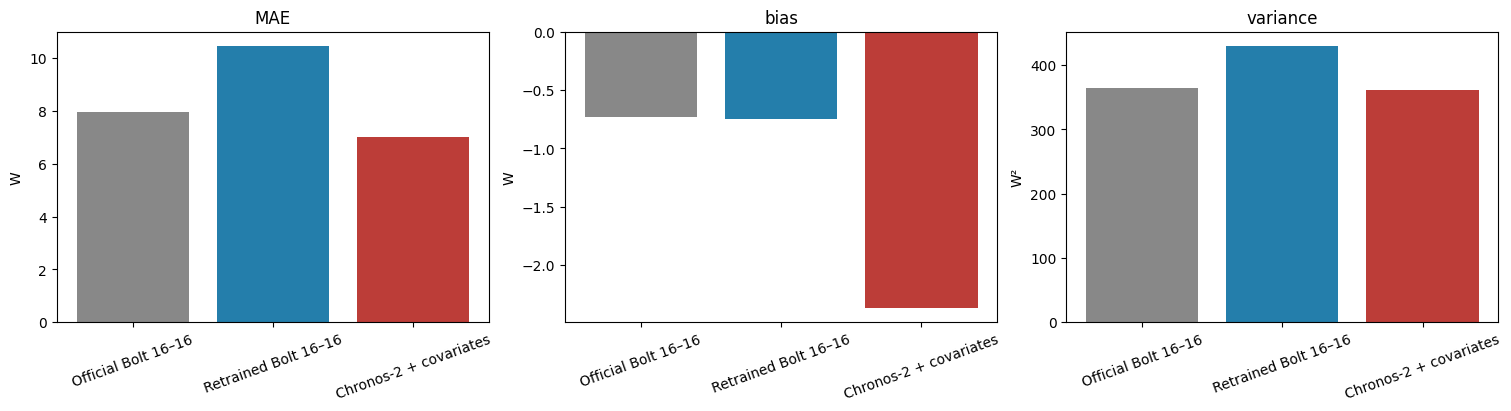

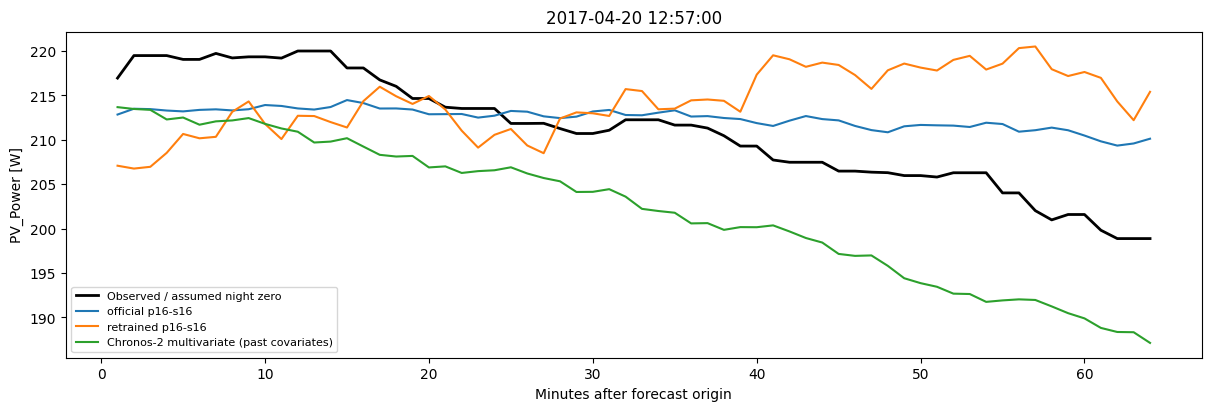

In [3]:
TABLE, PREDICTIONS, TARGETS, WINDOWS, OUTPUT = chronos2_benchmark.run_comparison(
    CSV_PATH, ROOT_OUTPUT, CONFIG, device=DEVICE)
display(TABLE)
print('Saved:', OUTPUT)
for figure in chronos2_benchmark.plot_comparison(TABLE, PREDICTIONS, TARGETS, WINDOWS, OUTPUT):
    display(figure)
    plt.close(figure)
